# Flujo Completo: DXF a Columnas Discretizadas

Este notebook muestra el proceso completo desde la lectura del archivo DXF hasta la discretización de columnas con todos los gráficos.

In [22]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "dynaengine").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from dynaengine import (
    extract_columns_from_dxf,
    prepare_column_configs,
    process_column_config,
    plot_dxf_extraction,
    plot_raw_column,
    plot_discretized_column,
    plot_column_discretized_detailed,
)
import matplotlib.pyplot as plt
import pandas as pd

## 1. Definición de Materiales

Mismos materiales del notebook 03_columns_from_dxf

In [2]:
MATERIALS = [
    {
        "material_name": "Material de poza",
        "unit_weight_kn_m3": 19,
        "shear_velocity": {"depth": [0, 5, 10, 15], "vs": [300, 350, 440, 550]},
        "shear_properties": {"c": 0, "phi": 34},
        "dynamic_model": {
            "model_type": "darendeli_2001",
            "sigma_vertical": 100,
            "soil_parameters": {"IP": 0.0, "OCR": 1.0, "k0": 0.7, "frequency": 1.0, "N": 10},
        },
    },
    {
        "material_name": "Material del dique",
        "unit_weight_kn_m3": 20,
        "shear_velocity": {"depth": [0, 8, 15, 20], "vs": [320, 380, 420, 550]},
        "shear_properties": {"c": 0, "phi": 34},
        "dynamic_model": {
            "model_type": "menq_2003",
            "sigma_vertical": 100,
            "soil_parameters": {"Cu": 18.0, "D50": 8.0, "k0": 0.7, "N": 10},
        },
    },
    {
        "material_name": "Grava arcillosa",
        "unit_weight_kn_m3": 19,
        "shear_velocity": {"depth": [0, 10, 20, 25], "vs": [200, 330, 540, 600]},
        "shear_properties": {"c": 0, "phi": 34},
        "dynamic_model": {
            "model_type": "wang_2021",
            "sigma_vertical": 100,
            "soil_parameters": {"soil_group": "Nonplastic silty sand group", "Cu": 2.0, "CF": 50.0, "e": 0.7, "D50": 1.0, "wc": 1.0, "k0": 0.7},
        },
    },
    {
        "material_name": "Grava arenosa",
        "unit_weight_kn_m3": 19,
        "shear_velocity": {"depth": [0, 24, 30, 40], "vs": [230, 300, 440, 700]},
        "shear_properties": {"c": 0, "phi": 34},
        "dynamic_model": {
            "model_type": "rollins_2020",
            "sigma_vertical": 100,
            "soil_parameters": {"Cu": 1.0, "k0": 1.0},
        },
    },
    {
        "material_name": "Grava pobremente gradada",
        "unit_weight_kn_m3": 19.0,
        "shear_velocity": {"depth": [0, 24, 30, 35], "vs": [230, 300, 440, 500]},
        "shear_properties": {"c": 0, "phi": 34},
        "dynamic_model": {
            "model_type": "ishibashi_1993",
            "sigma_vertical": 100,
            "soil_parameters": {"IP": 50.0, "k0": 0.5},
        },
    },
    {
        "material_name": "Estrato no identificado 1",
        "unit_weight_kn_m3": 19.0,
        "shear_velocity": {"depth": [0, 24, 30, 35], "vs": [230, 300, 440, 550]},
        "shear_properties": {"c": 0, "phi": 34},
        "dynamic_model": {
            "model_type": "rojas_2019",
            "sigma_vertical": 100,
            "soil_parameters": {"k0": 1.0},
        },
    },
]

## 2. Lectura del Archivo DXF

In [3]:
dxf_path = ROOT / "examples" / "data" / "section_01.dxf"

# Extraer columnas del DXF
extraction = extract_columns_from_dxf(dxf_path, x_positions=[250, 480])

print(f"Materiales encontrados: {extraction.material_names}")
print(f"Materiales no identificados: {extraction.unidentified_materials}")
print(f"Columnas extraídas: {list(extraction.columns.keys())}")

Materiales encontrados: ['Estrato no identificado 1', 'Grava arcillosa', 'Grava arenosa', 'Grava pobremente gradada', 'Material de poza']
Materiales no identificados: ['Estrato no identificado 1']
Columnas extraídas: ['section_01-column_1-failure_3', 'section_01-column_2-failure_7']


## 3. Visualización del DXF Leído

Se muestra el DXF con las secciones coloreadas por material. Las líneas verticales rojas indican las posiciones x donde se extraen las columnas.

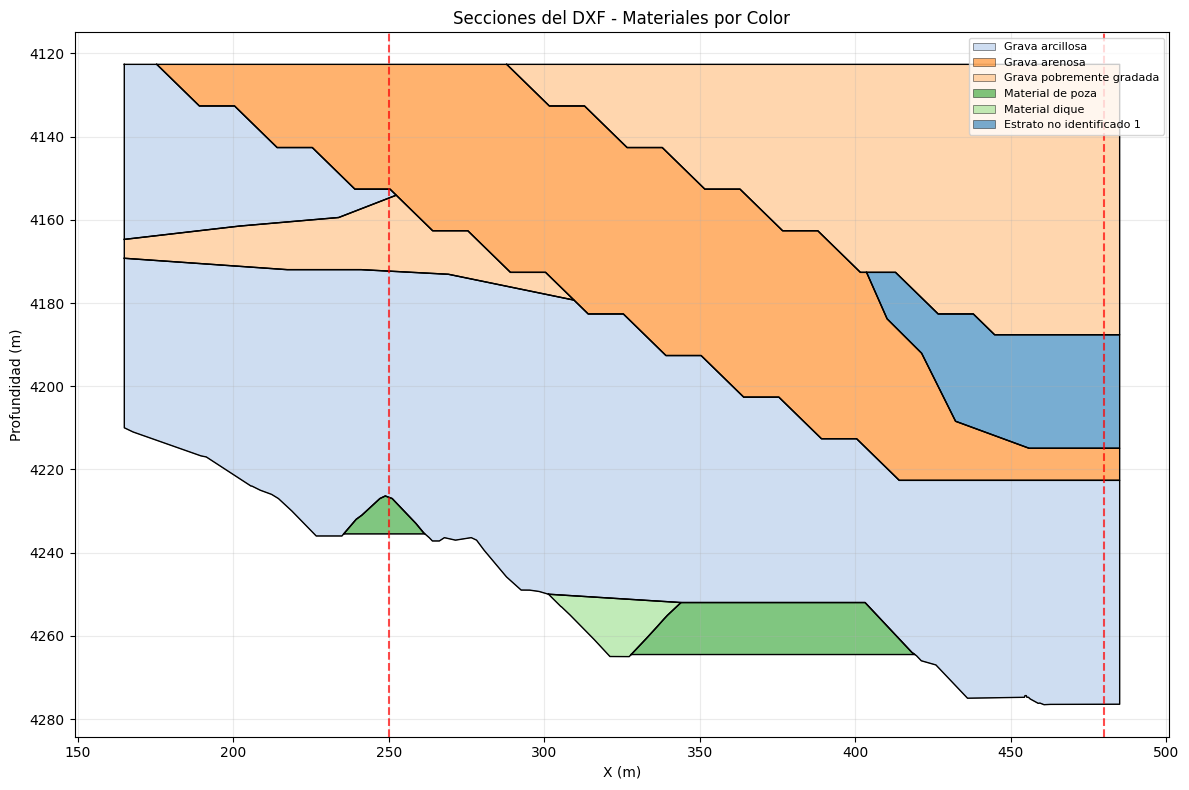

In [4]:
# Nota: Para plotear el DXF, necesitamos los polígonos limpios.
# Extraemos de nuevo con acceso a los datos internos
from dynaengine.dxf import (
    _read_dxf_layers,
    _generate_clean_polygons,
)

external, freatic, material, failure, text = _read_dxf_layers(dxf_path)
clean_polygons = _generate_clean_polygons(external, material, text)

# Plotear
fig, ax = plot_dxf_extraction(clean_polygons, x_positions=[250, 480])
plt.show()

## 4. Preparación de Configuraciones de Columna

In [5]:
# Preparar configuraciones para cada columna
configs = prepare_column_configs(
    extraction.columns,
    MATERIALS,
    target_frequency_hz=25
)

print(f"Configuraciones preparadas para: {list(configs.keys())}")

Configuraciones preparadas para: ['section_01-column_1-failure_3', 'section_01-column_2-failure_7']


## 5. Procesamiento de Primera Columna

Extraemos y discretizamos la primera columna.

In [6]:
# Procesar la primera columna
first_name = next(iter(configs))
result = process_column_config(configs[first_name], calibrate=False)

print(f"\nColumna procesada: {first_name}")
print(f"\nCapas no discretizadas: {len(result.raw)}")
print(f"Segmentos discretizados: {len(result.discretized)}")
print(f"\nPropiedad 'natural_frequency_hz' presente: {'natural_frequency_hz' in result.discretized.columns}")


Columna procesada: section_01-column_1-failure_3

Capas no discretizadas: 5
Segmentos discretizados: 35

Propiedad 'natural_frequency_hz' presente: True


### 5.1 Datos de Columna No Discretizada

In [7]:
result.raw[["layer_id", "material_name", "top_m", "bottom_m", "thickness_m", "shear_velocity_m_s"]].head(10)

,layer_id,material_name,top_m,bottom_m,thickness_m,shear_velocity_m_s
0,1,Material de poza,0.00000,8.80462,8.80462,319.737697
1,2,Grava arcillosa,8.80462,63.17001,54.36539,498.052817
2,3,Grava pobremente gradada,63.17001,80.72154,17.55153,500.000000
3,4,Grava arcillosa,80.72154,82.87277,2.15123,600.000000
4,5,Grava arenosa,82.87277,112.87257,29.99980,700.000000


### 5.2 Gráfico de Columna No Discretizada

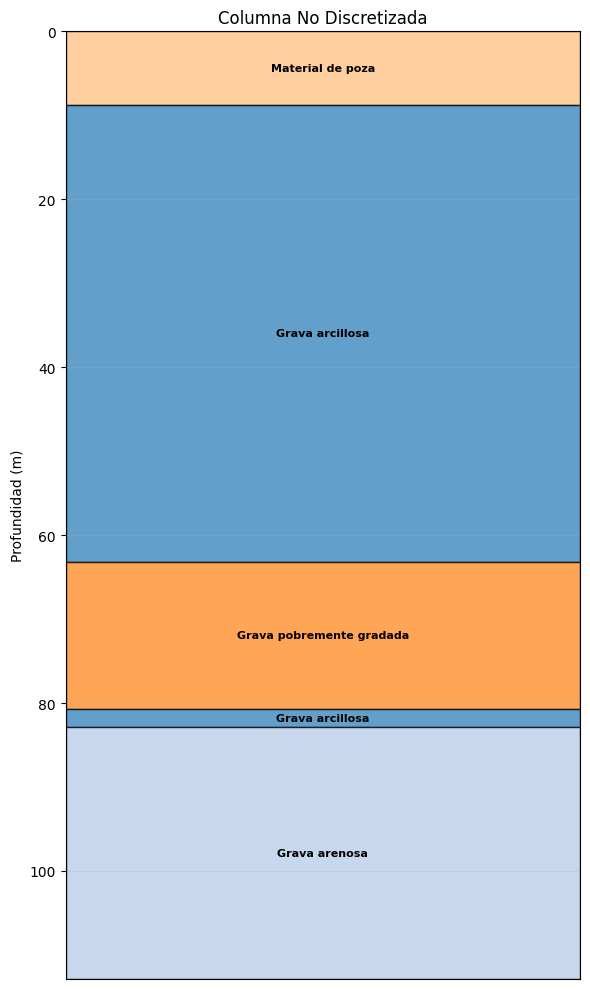

In [8]:
fig, ax = plot_raw_column(result.raw)
plt.show()

### 5.3 Datos de Columna Discretizada

In [9]:
result.discretized[[
    "segment_id", "material_name", "top_m", "bottom_m", "thickness_m",
    "shear_velocity_m_s", "natural_frequency_hz"
]].head(15)

,segment_id,material_name,top_m,bottom_m,thickness_m,shear_velocity_m_s,natural_frequency_hz
0,1,Material de poza,0.000000,2.934873,2.934873,300.000000,25.554766
1,2,Material de poza,2.934873,5.869747,2.934873,313.262130,26.684468
2,3,Material de poza,5.869747,8.804620,2.934873,350.000000,29.813893
3,4,Grava arcillosa,8.804620,11.275774,2.471154,251.060011,25.399065
4,5,Grava arcillosa,11.275774,13.746928,2.471154,330.000000,33.385211
5,6,Grava arcillosa,13.746928,16.218082,2.471154,330.000000,33.385211
6,7,Grava arcillosa,16.218082,18.689236,2.471154,330.000000,33.385211
7,8,Grava arcillosa,18.689236,21.160390,2.471154,403.725149,40.843785
8,9,Grava arcillosa,21.160390,23.631545,2.471154,540.000000,54.630345
9,10,Grava arcillosa,23.631545,26.102699,2.471154,565.221790,57.181965


### 5.4 Gráfico Simple de Columna Discretizada

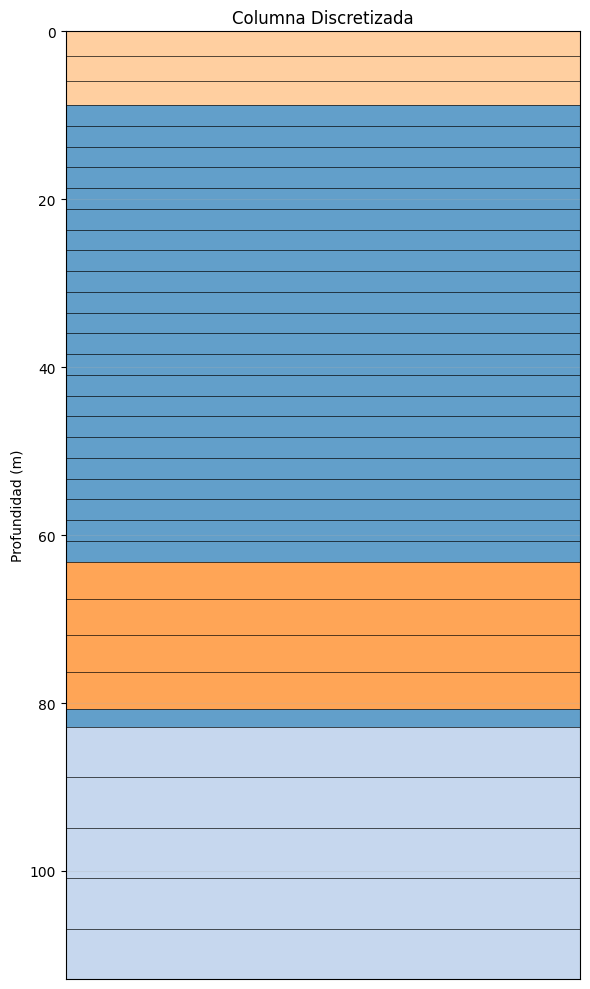

In [10]:
fig, ax = plot_discretized_column(result.discretized)
plt.show()

### 5.5 Gráfico Detallado de Columna Discretizada

Muestra 4 vistas simultáneamente:
- **Materiales**: Colores diferenciados por material
- **Espesor**: Thickness (m) de cada estrato
- **Perfil Vs**: Velocidad de onda de corte (m/s) de cada segmento
- **Perfil de Frecuencia**: Frecuencia natural (Hz) de cada estrato

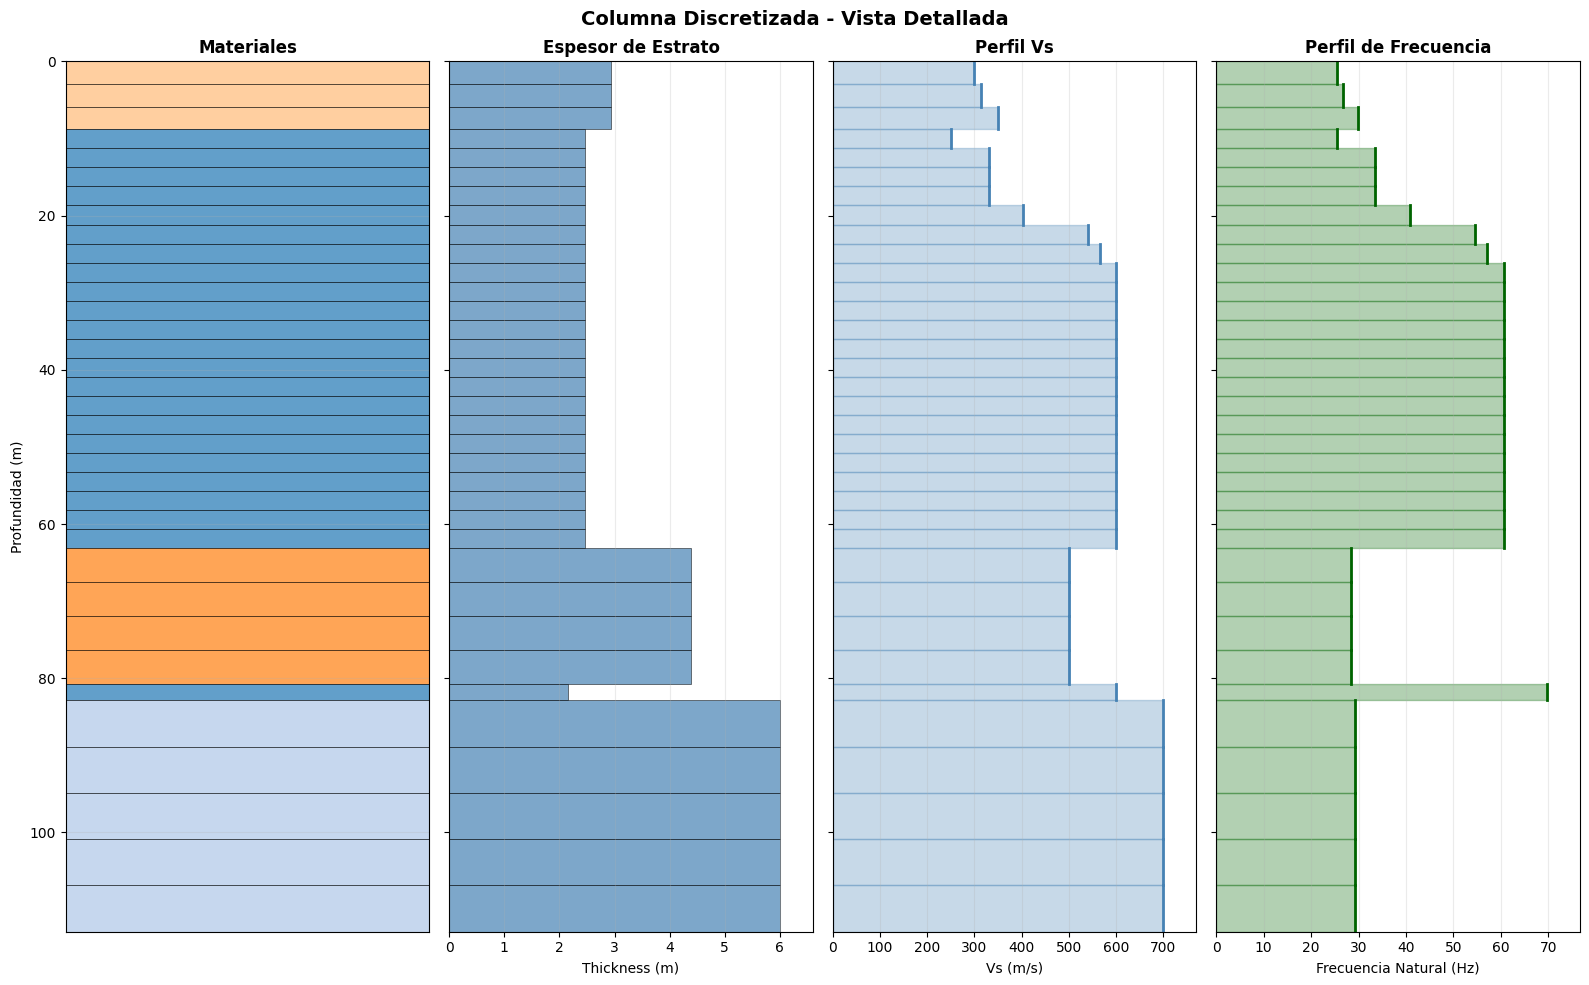

In [11]:
fig, axes = plot_column_discretized_detailed(result.discretized)
plt.show()

## 6. Procesamiento de Segunda Columna

Repetimos el proceso para la segunda columna.

In [12]:
# Procesar la segunda columna
second_name = list(configs.keys())[1]
result2 = process_column_config(configs[second_name], calibrate=False)

print(f"Columna procesada: {second_name}")
print(f"Capas no discretizadas: {len(result2.raw)}")
print(f"Segmentos discretizados: {len(result2.discretized)}")

Columna procesada: section_01-column_2-failure_7
Capas no discretizadas: 4
Segmentos discretizados: 47


### 6.1 Gráfico Detallado de Segunda Columna

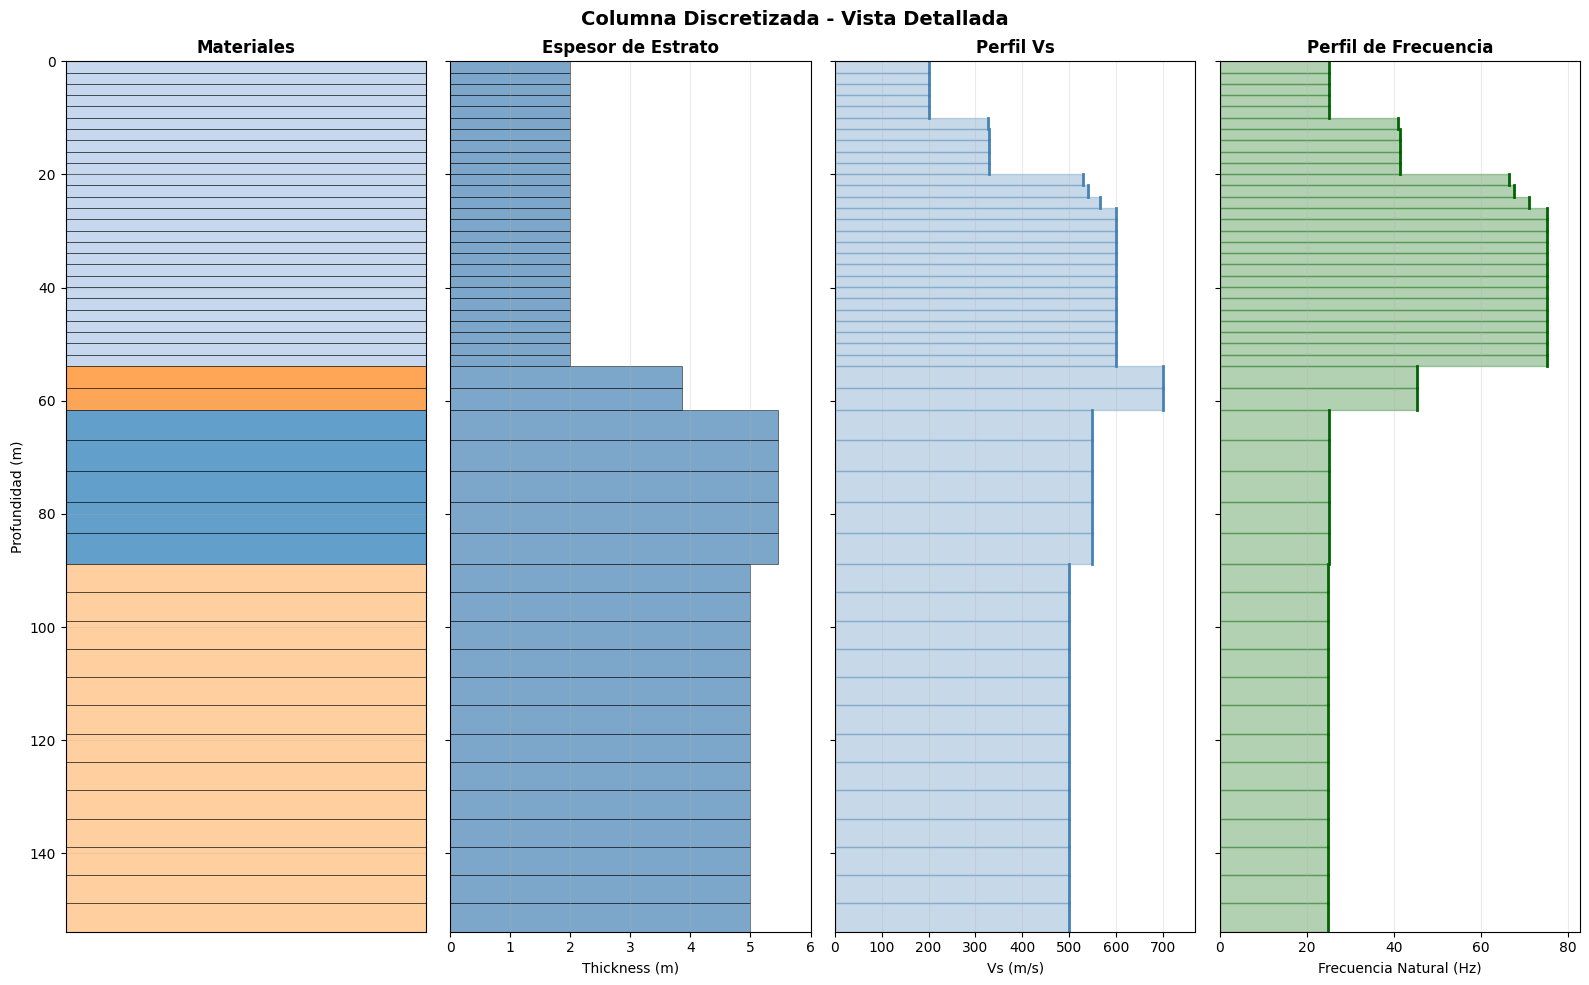

In [13]:
fig, axes = plot_column_discretized_detailed(result2.discretized)
plt.show()

## 7. Comparación de Perfiles Vs entre Columnas

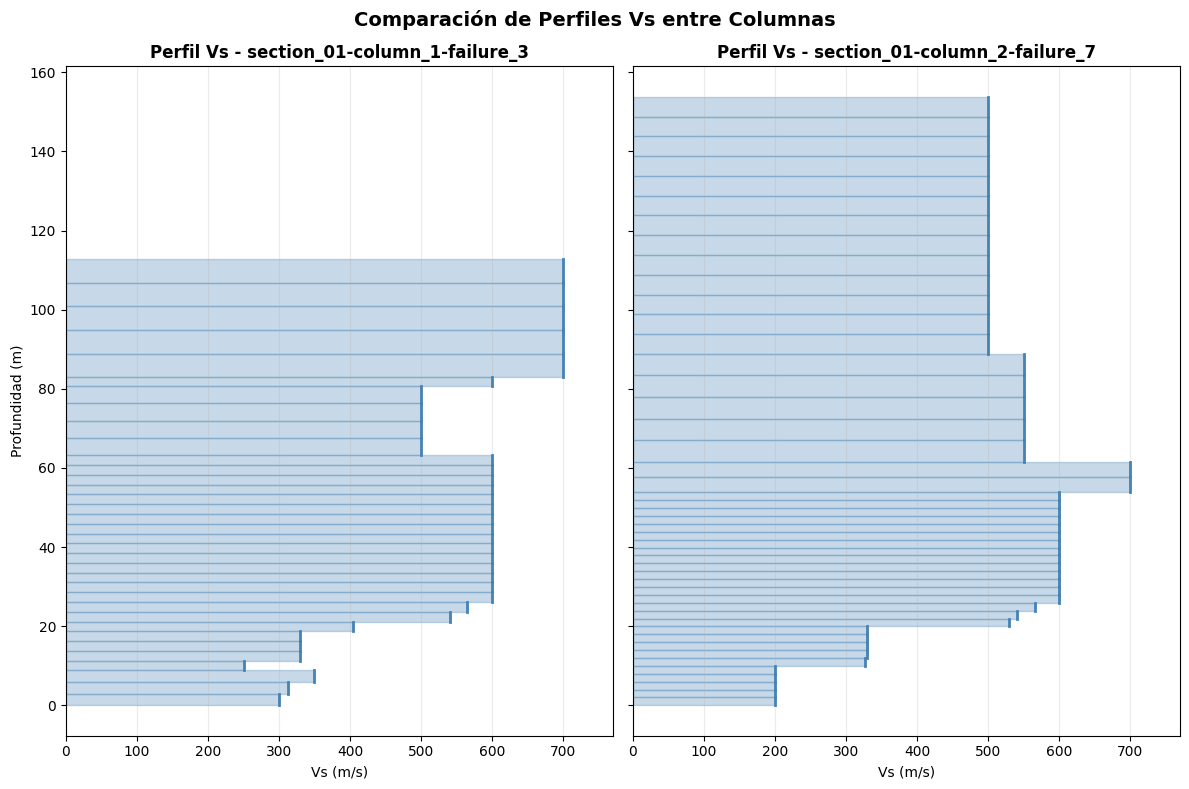

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 8), sharey=True)

for idx, (result_data, column_name, ax) in enumerate([
    (result, first_name, axes[0]),
    (result2, second_name, axes[1]),
]):
    disc = result_data.discretized
    max_vs = disc["shear_velocity_m_s"].max()
    
    for _, row in disc.iterrows():
        top = row["top_m"]
        bottom = row["bottom_m"]
        vs = row["shear_velocity_m_s"]
        
        ax.plot([vs, vs], [top, bottom], color="steelblue", linewidth=2)
        ax.fill_betweenx([top, bottom], 0, [vs, vs], alpha=0.3, color="steelblue")
    
    ax.set_xlim(0, max_vs * 1.1)
    ax.invert_yaxis()
    ax.set_xlabel("Vs (m/s)")
    ax.set_title(f"Perfil Vs - {column_name}", weight="bold")
    ax.grid(True, axis="x", alpha=0.25)

axes[0].set_ylabel("Profundidad (m)")
fig.suptitle("Comparación de Perfiles Vs entre Columnas", fontsize=14, weight="bold")
fig.tight_layout()
plt.show()

## 8. Análisis comparativo de columnas

In [20]:
# Procesar todas las columnas
all_results = {}
for col_name, config in configs.items():
    result = process_column_config(config, calibrate=False)
    all_results[col_name] = result
    print(f"✓ {col_name}: {len(result.discretized)} segmentos")

print(f"\nTotal de columnas procesadas: {len(all_results)}")

✓ section_01-column_1-failure_3: 35 segmentos
✓ section_01-column_2-failure_7: 47 segmentos

Total de columnas procesadas: 2


## 9. Comparación de propiedades

In [21]:
# Resumen comparativo de todas las columnas
summary_data = []
for col_name, result in all_results.items():
    raw_df = result.raw
    disc_df = result.discretized
    summary_data.append({
        "Columna": col_name,
        "Capas (Raw)": len(raw_df),
        "Segmentos (Disc)": len(disc_df),
        "Profundidad (m)": raw_df["bottom_m"].max(),
        "Vs Promedio (m/s)": raw_df["shear_velocity_m_s"].mean(),
        "γ Promedio (kN/m³)": raw_df["unit_weight_kn_m3"].mean(),
    })

summary_df = pd.DataFrame(summary_data)
print("\nResumen Comparativo de Columnas:")
print(summary_df.to_string(index=False))


Resumen Comparativo de Columnas:
                      Columna  Capas (Raw)  Segmentos (Disc)  Profundidad (m)  Vs Promedio (m/s)  γ Promedio (kN/m³)
section_01-column_1-failure_3            5                35        112.87257         523.558103                19.0
section_01-column_2-failure_7            4                47        153.82703         535.291366                19.0


## 10. Distribución de materiales

In [23]:
# Análisis de distribución de materiales
material_summary = []
for col_name, result in all_results.items():
    raw_df = result.raw
    for material in raw_df["material_name"].unique():
        material_data = raw_df[raw_df["material_name"] == material]
        material_summary.append({
            "Columna": col_name,
            "Material": material,
            "Número de Capas": len(material_data),
            "Espesor Total (m)": material_data["thickness_m"].sum(),
            "Profundidad Superior (m)": material_data["top_m"].min(),
            "Profundidad Inferior (m)": material_data["bottom_m"].max(),
            "Vs Promedio (m/s)": material_data["shear_velocity_m_s"].mean(),
        })

material_df = pd.DataFrame(material_summary)
print("\nDistribución de Materiales por Columna:")
print(material_df.to_string(index=False))


Distribución de Materiales por Columna:
                      Columna                  Material  Número de Capas  Espesor Total (m)  Profundidad Superior (m)  Profundidad Inferior (m)  Vs Promedio (m/s)
section_01-column_1-failure_3          Material de poza                1            8.80462                   0.00000                   8.80462         319.737697
section_01-column_1-failure_3           Grava arcillosa                2           56.51662                   8.80462                  82.87277         549.026409
section_01-column_1-failure_3  Grava pobremente gradada                1           17.55153                  63.17001                  80.72154         500.000000
section_01-column_1-failure_3             Grava arenosa                1           29.99980                  82.87277                 112.87257         700.000000
section_01-column_2-failure_7           Grava arcillosa                1           53.82763                   0.00000                  53.82763 

## 11. Exportar resultados

In [24]:
# Opcionalmente, guardar resultados en CSV
output_dir = ROOT / "results"
output_dir.mkdir(exist_ok=True)

for col_name, result in all_results.items():
    raw_file = output_dir / f"{col_name}_raw.csv"
    disc_file = output_dir / f"{col_name}_discretized.csv"
    
    result.raw.to_csv(raw_file, index=False)
    result.discretized.to_csv(disc_file, index=False)
    print(f"✓ Guardado: {raw_file}")
    print(f"✓ Guardado: {disc_file}")

# Guardar resúmenes
summary_df.to_csv(output_dir / "columns_summary.csv", index=False)
material_df.to_csv(output_dir / "materials_summary.csv", index=False)
print(f"\n✓ Resúmenes guardados en: {output_dir}")

✓ Guardado: C:\Users\joel.alarcon\Desktop\_code\DynaEngine\results\section_01-column_1-failure_3_raw.csv
✓ Guardado: C:\Users\joel.alarcon\Desktop\_code\DynaEngine\results\section_01-column_1-failure_3_discretized.csv
✓ Guardado: C:\Users\joel.alarcon\Desktop\_code\DynaEngine\results\section_01-column_2-failure_7_raw.csv
✓ Guardado: C:\Users\joel.alarcon\Desktop\_code\DynaEngine\results\section_01-column_2-failure_7_discretized.csv

✓ Resúmenes guardados en: C:\Users\joel.alarcon\Desktop\_code\DynaEngine\results
